# esmDMS Simulation!!

Benchmarking out inference methods with perfect data!

In [90]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import rc
from numpy.linalg import inv 
from sklearn import linear_model 
import stan

In [91]:
rc('text', usetex=True)
pd.set_option('display.max_columns', 100)
pwd = os.getcwd()

init_pop = pd.read_pickle(pwd + '/data/sequence_data/all_reps_BF520_protein_embeddings.pkl')

init_pop = init_pop[init_pop['Embeddings'].notna()].reset_index(drop=True)

In [92]:
# Combine the prenums and postnums of any entries with the same potein sequence
init_pop['PreNums'] = init_pop['PreNums'].apply(lambda x: np.array(x))
init_pop['PostNums'] = init_pop['PostNums'].apply(lambda x: np.array(x))
init_pop_grouped = init_pop.groupby('ProteinSequence').agg({
    'PreNums': lambda x: np.sum(x.tolist(), axis=0),
    'PostNums': lambda x: np.sum(x.tolist(), axis=0),
    'Embeddings': 'first'
}).reset_index()

In [93]:
init_pop_grouped

,ProteinSequence,PreNums,PostNums,Embeddings
0,A*NLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[39, 47, 53]","[8, 5, 6]","[[-0.031513277, -0.027529575, -0.043846164, -0..."
1,AANLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[16, 13, 18]","[9, 6, 10]","[[-0.03163178, -0.02769079, -0.04372052, -0.01..."
2,ACNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[7, 6, 6]","[6, 2, 5]","[[-0.031665795, -0.027563317, -0.043822058, -0..."
3,ADNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[14, 8, 3]","[2, 6, 6]","[[-0.03162248, -0.027495803, -0.043818824, -0...."
4,AENLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[29, 46, 34]","[72, 68, 93]","[[-0.031206096, -0.027565997, -0.043747563, -0..."
...,...,...,...,...
13167,GGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[0, 2, 0]","[0, 0, 1]","[[-0.031604197, -0.027621143, -0.043950938, -0..."
13168,PGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[1, 0, 0]","[1, 1, 1]","[[-0.03163283, -0.027663246, -0.043426607, -0...."
13169,SGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[2, 7, 0]","[1, 5, 3]","[[-0.031612042, -0.02763081, -0.043894112, -0...."
13170,TGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...,"[110, 164, 94]","[114, 173, 207]","[[-0.031634934, -0.027693663, -0.043913726, -0..."


In [94]:
np.random.seed(0)

# Make dataframes for each of the three replicates
replicate_dfs = []
n_reps = 3
for rep in range(n_reps):
    df_rep = init_pop_grouped.copy()
    df_rep['PreNums'] = df_rep['PreNums'].apply(lambda x: x[rep])
    df_rep['PostNums'] = df_rep['PostNums'].apply(lambda x: x[rep])
    df_rep = df_rep.drop(columns=['ProteinSequence'])
    replicate_dfs.append(df_rep)
replicate_dfs[0]

,PreNums,PostNums,Embeddings
0,39,8,"[[-0.031513277, -0.027529575, -0.043846164, -0..."
1,16,9,"[[-0.03163178, -0.02769079, -0.04372052, -0.01..."
2,7,6,"[[-0.031665795, -0.027563317, -0.043822058, -0..."
3,14,2,"[[-0.03162248, -0.027495803, -0.043818824, -0...."
4,29,72,"[[-0.031206096, -0.027565997, -0.043747563, -0..."
...,...,...,...
13167,0,0,"[[-0.031604197, -0.027621143, -0.043950938, -0..."
13168,1,1,"[[-0.03163283, -0.027663246, -0.043426607, -0...."
13169,2,1,"[[-0.031612042, -0.02763081, -0.043894112, -0...."
13170,110,114,"[[-0.031634934, -0.027693663, -0.043913726, -0..."


In [95]:
num_layers = replicate_dfs[0]['Embeddings'][0].shape[0]

# decompose the embeddings for each replicate and layer
decomposed_dfs = []
for rep_df in replicate_dfs:
    decomposed_df = rep_df[['PreNums', 'PostNums']].copy()
    
    for layer in range(num_layers):
        decomposed_df[f'Layer{layer}'] = rep_df['Embeddings'].apply(lambda x: x[layer])
    decomposed_dfs.append(decomposed_df)

In [96]:
for layer in range(num_layers):
    print(decomposed_dfs[0][f'Layer{layer}'].iloc[0].shape) # ALL (640,)

(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)
(640,)


In [97]:
# Let's choose Layer 12 for funzies
selected_layer = 12
df_selection = pd.DataFrame()
for i, decomposed_df in enumerate(decomposed_dfs):
    df_selection[f'Rep{i+1}_PreNums'] = decomposed_df['PreNums']
    df_selection[f'Rep{i+1}_PostNums'] = decomposed_df['PostNums']
df_selection[f'Embedding'] = decomposed_df[f'Layer{selected_layer}']


In [98]:
df_selection

,Rep1_PreNums,Rep1_PostNums,Rep2_PreNums,Rep2_PostNums,Rep3_PreNums,Rep3_PostNums,Embedding
0,39,8,47,5,53,6,"[-0.59095, -0.20893419, -1.074131, -0.5501634,..."
1,16,9,13,6,18,10,"[-0.5835699, -0.20366529, -1.0667843, -0.55543..."
2,7,6,6,2,6,5,"[-0.59919953, -0.22746255, -1.0731624, -0.5670..."
3,14,2,8,6,3,6,"[-0.59044176, -0.22718638, -1.086812, -0.55924..."
4,29,72,46,68,34,93,"[-0.5861342, -0.23495646, -1.0848683, -0.56606..."
...,...,...,...,...,...,...,...
13167,0,0,2,0,0,1,"[-0.58649033, -0.22007006, -1.0617292, -0.5396..."
13168,1,1,0,1,0,1,"[-0.594706, -0.20239507, -1.0794948, -0.540265..."
13169,2,1,7,5,0,3,"[-0.5857174, -0.21249211, -1.075183, -0.542879..."
13170,110,114,164,173,94,207,"[-0.57897925, -0.21528694, -1.0847609, -0.5478..."


In [99]:
# Now, let's calculate the fitness for each variant based on its embedding and the selection coefficients
def calculate_fitness_exp(embedidng, selection_coefficients):
    return np.exp(np.dot(embedidng, selection_coefficients))

def calculate_fitness_plus1(embedidng, selection_coefficients):
    return 1 + np.dot(embedidng, selection_coefficients)

def simulate_generation_multinomial(current_counts, fitnesses):
    population_size = np.sum(current_counts)
    total_fitness = np.sum(current_counts * fitnesses)
    probabilities = (current_counts * fitnesses) / total_fitness
    next_counts = np.random.multinomial(population_size, probabilities)
    return next_counts


In [100]:
# Generate some random selection coefficients for the 640 dimensions
np.random.seed(42)
selection_coefficients = np.random.normal(loc=0.0, scale=0.1, size=640)

embeddings = np.vstack(df_selection['Embedding'].values)
fitnesses_exp = calculate_fitness_exp(embeddings, selection_coefficients)
fitnesses_plus1 = calculate_fitness_plus1(embeddings, selection_coefficients)

start_counts1 = df_selection["Rep1_PreNums"].values
start_counts2 = df_selection["Rep2_PreNums"].values
start_counts3 = df_selection["Rep3_PreNums"].values

In [101]:
# Running the Simulation

generation_counts = [[start_counts1, start_counts2, start_counts3]]
n_gens = 30

use_fit = fitnesses_plus1

for gen in range(n_gens):
    gen_counts = generation_counts[-1]
    this_gen = []
    for rep in range(n_reps):
        # Generate a new set of generation_counts: [rep1_counts, rep2_counts, rep3_counts]
        # append them to the generation_counts list
        rep_counts = gen_counts[rep]
        next_counts = simulate_generation_multinomial(rep_counts, use_fit)
        this_gen.append(next_counts)
    generation_counts.append(this_gen)
        

In [102]:
# Now, calculate selectiion_coefficitents from the generational counts

import popDMS
import pandas as pd
import pickle
from importlib import reload

# reload popDMS
reload(popDMS)


def simulation_df_transfer(df_selection, generation_counts):
    #["Generation", "Embedding", "Frequency", "Replicate"]
    emb_vals = df_selection["Embedding"].values
    #generation counts format [[gen1data], [gen2data],...]
    data_list = []
    for gen, gen_data in enumerate(generation_counts):
        for rep, rep_data in enumerate(gen_data):
            for i, count in enumerate(rep_data):
                data_list.append({
                    "Generation": gen,
                    "Embedding": emb_vals[i],
                    "Frequency": count,
                    "Replicate": rep + 1
                })
    return pd.DataFrame(data_list)

def run_inference_calcs_sims(df_selection, generation_counts, output_path):
    """Run the inference calculations:
    WHOLE PIPELINE FROM READING IN EMBEDDINGS DATAFRAME
    """
    inference_df = simulation_df_transfer(df_selection, generation_counts)
    
    # make directory
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    # save inference_df
    inference_df.to_pickle(output_path + 'inference_df.pkl')
    print(f"SAVED INFERENCE DF TO {output_path}")
    
    inference_df = pd.read_pickle(output_path + 'inference_df.pkl')    
    data = popDMS.mini_infer_independent_esm(inference_df, n_replicates=3,
                                            output_dir=output_path)
    return data # data = [dx, icov, s, s_joint, sel_data, gamma_opt, x_array]


SAVED INFERENCE DF TO /Users/dylanwells/CodingProjects/popDMS/esmDMS/simulations/
corrs_list: [[np.float64(0.7703766753674915), np.float64(0.46015609531079216), np.float64(0.8543141397340184)], [np.float64(0.7703766757360184), np.float64(0.4601560960072951), np.float64(0.8543141398513929)], [np.float64(0.7703766761693571), np.float64(0.4601560968262796), np.float64(0.8543141399893985)], [np.float64(0.7703766766789), np.float64(0.46015609778927835), np.float64(0.854314140151649)], [np.float64(0.770376677278062), np.float64(0.4601560989216247), np.float64(0.8543141403424968)], [np.float64(0.7703766779825597), np.float64(0.46015610025308984), np.float64(0.8543141405668444)], [np.float64(0.7703766788109635), np.float64(0.4601561018186907), np.float64(0.8543141408306801)], [np.float64(0.7703766797850315), np.float64(0.4601561036596106), np.float64(0.854314141140893)], [np.float64(0.7703766809303981), np.float64(0.46015610582424693), np.float64(0.8543141415056685)], [np.float64(0.77037668227

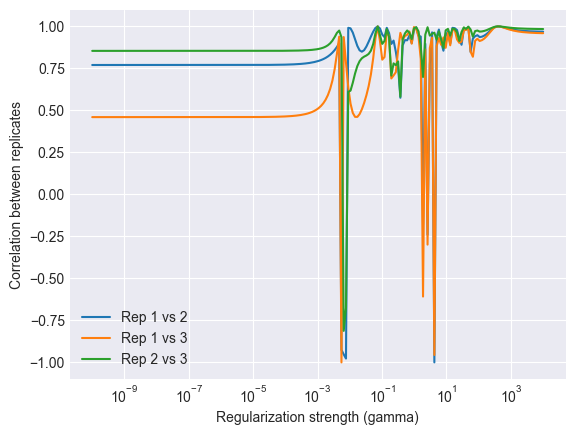

Found best regularization strength gamma = 2.8e+02, R = 0.99


In [103]:
test_path = pwd + "/simulations/"
plt.rcParams['text.usetex'] = False
test = run_inference_calcs_sims(df_selection, generation_counts, test_path)

In [104]:
# data = [dx, icov, s, s_joint, sel_data, gamma_opt, x_array]
found_sel_coeffs = test[2]


print(selection_coefficients.shape)
print(found_sel_coeffs.shape)

(640,)
(3, 640)


(640,) (640,)
(640,) (640,)
(640,) (640,)


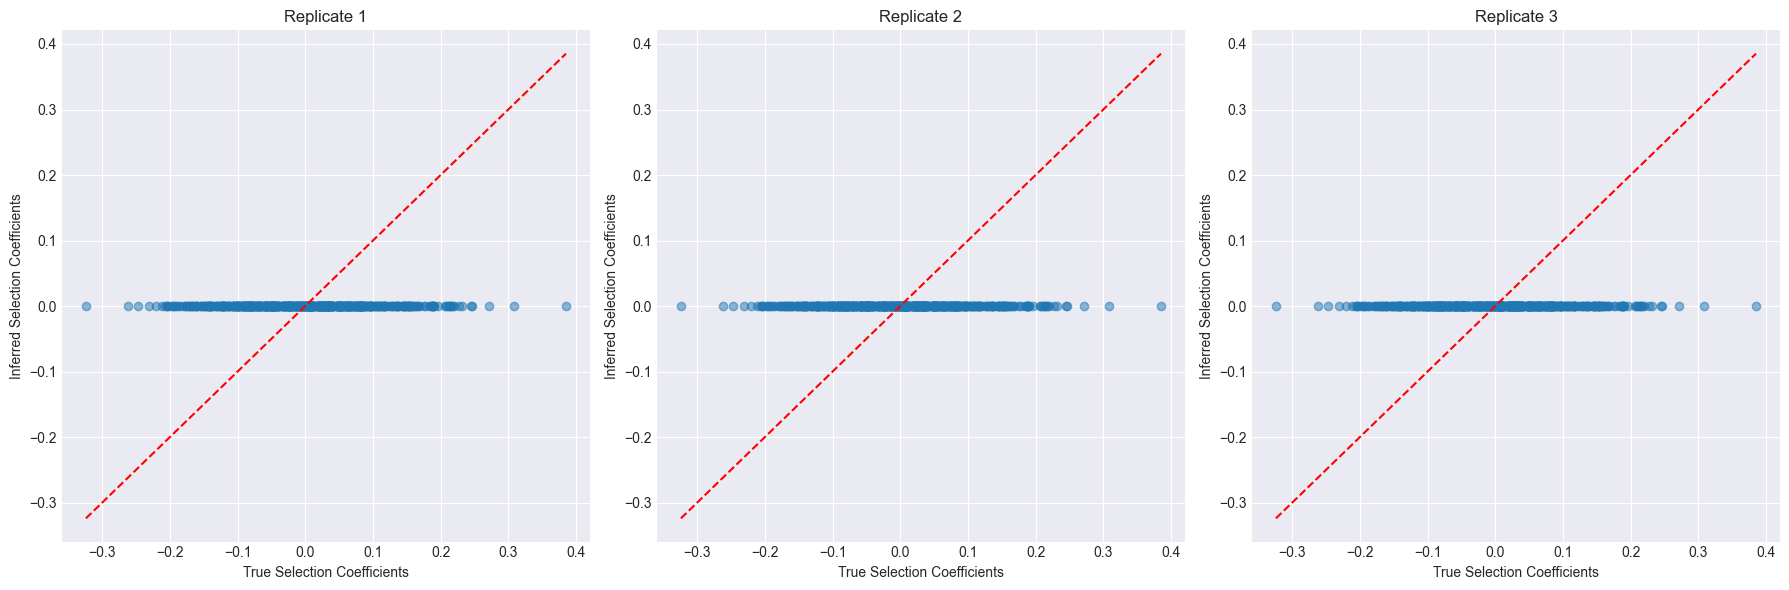

In [105]:
# Plot the true vs inferred selection coefficients for all three replicates on 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))


plt.style.use('seaborn-v0_8-darkgrid')
for rep in range(3):
    x = selection_coefficients
    y = found_sel_coeffs[rep]
    print(x.shape, y.shape)
    
    
    axs[rep].scatter(x, y, alpha=0.5)
    axs[rep].set_title(f'Replicate {rep + 1}')
    axs[rep].set_xlabel('True Selection Coefficients')
    axs[rep].set_ylabel('Inferred Selection Coefficients')
    axs[rep].plot([min(selection_coefficients), max(selection_coefficients)],
                  [min(selection_coefficients), max(selection_coefficients)],
                  color='red', linestyle='--')
plt.tight_layout()
plt.show()




## Simulate other methods and compare

In [106]:
def other_methods(replicates, finite_sampling, generation_list, regularization=1):
    inferred_log = {}
    inferred_ratio = {}
    inferred_regression = {}
    inferred_selection = {}
    for generation in generation_list:
        inferred_log[generation] = []
        inferred_ratio[generation] = []
        inferred_regression[generation] = []
        inferred_selection[generation] = []

    for rep_num in range(replicates):        
        plot_list_all=pd.read_csv('./output/simulation/WF_finite_sampling/'+'rep-%s.csv.zip' %rep_num, index_col=0)
        plot_list_all = plot_list_all.T
        regression_list = plot_list_all.copy().T
        regression_list = np.log(regression_list)
        regression_list = regression_list.T
        regression_list['generation'] = [i for i in range(regression_list.shape[0])]
        plot_list_all['generation'] = [i for i in range(regression_list.shape[0])]
        # frequency change        
        for generation in generation_list:
            plot_list = plot_list_all.iloc[:generation]
            # frequency change
            freq_table = plot_list.drop('generation', axis=1).copy()

            freq_diff = freq_table.iloc[-1]-freq_table.iloc[0]
            freq_diff = np.array(freq_diff.tolist())

            # covariance/ vector
            cov_matx = np.zeros((21, 21))
            for gen in range(freq_table.shape[0]-1):
                variant_freq = freq_table.iloc[gen].tolist()
                for i in range(21):
                    cov_matx[i,i] += variant_freq[i]*(1-variant_freq[i])
                    for j in range(i+1,21):
                        cov_matx[i,j] -= variant_freq[i]*variant_freq[j]
                        cov_matx[j,i] -= variant_freq[i]*variant_freq[j]
                        
            selection = inv(cov_matx + np.identity(21)*regularization).dot(freq_diff)
            inferred_selection[generation].append(selection)

            # ratio
            raw = freq_table.iloc[-1]/freq_table.iloc[0]
            inferred_ratio[generation].append([i/sum(raw) for i in raw])

            # log enrich
            inferred_log[generation].append([np.log(i/sum(raw)) for i in raw])

            # log regression
            df_regression = regression_list.iloc[:generation].copy()
            temp_enrich = []
            for i in df_regression.columns[:-1]:
                Y = df_regression[i].values.reshape(-1, 1)
                X = df_regression['generation'].values.reshape(-1, 1)
                temp_enrich.append(linear_model.LinearRegression().fit(X,Y).coef_[0][0])
            inferred_regression[generation].append(temp_enrich)
        
    print("Saving popDMS inference with regularization = %.1f"%regularization)                   
    for generation in generation_list:
        df_enrichment_regress = pd.DataFrame(inferred_regression[generation])
        df_enrichment_ratio = pd.DataFrame(inferred_ratio[generation])
        df_enrichment_log = pd.DataFrame(inferred_log[generation])
        df_selection = pd.DataFrame(inferred_selection[generation])
        # df_enrichment_regress.to_csv('./output/simulation/WF_mutational_effects/'+'log_regression_gen-%s_'%(generation)+'sampling-%s'%finite_sampling+'.csv.zip', sep = ',', index = False, compression = 'zip')
        # df_enrichment_ratio.to_csv('./output/simulation/WF_mutational_effects/'+'enrichment_ratio_gen-%s_'%(generation)+'sampling-%s'%finite_sampling+'.csv.zip', sep = ',', index = False, compression = 'zip')
        # df_enrichment_log.to_csv('./output/simulation/WF_mutational_effects/'+'enrichment_ratio_log_gen-%s_'%(generation)+'sampling-%s'%finite_sampling+'.csv.zip', sep = ',', index = False, compression = 'zip')
        # df_selection.to_csv('./output/simulation/WF_mutational_effects/'+'selection_coefficients_gen-%s_'%(generation)+'sampling-%s'%finite_sampling+'.csv.zip', sep = ',', index = False, compression = 'zip')